# adaptive-intelligence v2: Local HuggingFace Demo
## Zero Rate Limits. Runs on Colab T4 GPU. Completely Free.

**Model:** `Qwen/Qwen2.5-1.5B-Instruct` (1.5B, loads in 30s, fits any GPU)  
**No API key. No rate limits. No signup.**  

**Before running:** Runtime > Change runtime type > T4 GPU

---

**Author:** [Venkatkumar R](https://linkedin.com/in/venkatkumarvk)  
**Library:** [PyPI](https://pypi.org/project/adaptive-intelligence/) | [GitHub](https://github.com/VK-Ant/adaptive-intelligence)  
**Paper:** [ResearchGate](https://www.researchgate.net/publication/405076088)  
**Also:** [llmevalkit](https://pypi.org/project/llmevalkit/) — 61 metrics for LLM evaluation


## Step 1: First Colab Environment
Run this cell, then **restart runtime** (Runtime > Restart runtime), then continue from Step 2.

In [5]:
import sys

# Fix PyTorch and torchvision/torchaudio issues in Colab
# Run this ONCE, then restart runtime, then skip this cell
# Uninstall existing torch and related packages to clear potential conflicts
!pip uninstall torch torchvision torchaudio -y -q

# Install PyTorch and related packages compatible with Colab's CUDA
# Using cu121 as a common compatible version for Colab's T4 GPUs.
# If this still fails, Colab's environment might have a different CUDA version,
# and you might need to adjust 'cu121' to 'cu118' or another specific version.
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 -q

print('Done. Now go to Runtime > Restart runtime, then run from Step 2.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 101.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 111.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 84.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 56.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 107.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 15.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━

## Step 2: Install (run after restart)

In [1]:
%%capture
!pip install adaptive-intelligence chromadb -q
!pip install transformers accelerate -q


## Step 3: Check GPU

In [4]:
import torch
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
else:
    print('No GPU. Go to Runtime > Change runtime type > T4 GPU')


CUDA: True
GPU: Tesla T4
VRAM: 14.6 GB


## Step 4: Load Model (~30 seconds)

In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import time

MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'

print(f'Loading {MODEL_NAME}...')
start = time.time()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map='auto',
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f'Loaded in {time.time()-start:.1f}s')
if torch.cuda.is_available():
    print(f'VRAM used: {torch.cuda.memory_allocated()/1024**3:.1f} GB')

# Quick test
def local_generate(prompt, system_prompt='You are a helpful assistant.', max_tokens=512):
    messages = [
        {'role': 'system', 'content': system_prompt},
        {'role': 'user', 'content': prompt},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=4096).to(model.device)
    input_len = inputs['input_ids'].shape[1]
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_tokens, temperature=0.1,
                             do_sample=True, pad_token_id=tokenizer.pad_token_id)
    return tokenizer.decode(out[0][input_len:], skip_special_tokens=True).strip()

test = local_generate('What is 2+2? One word answer.')
print(f'Test: {test}')
print('Model ready. Zero rate limits.')


Loading Qwen/Qwen2.5-1.5B-Instruct...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded in 42.0s
VRAM used: 2.9 GB
Test: 4
Model ready. Zero rate limits.


## Step 5: Create Test Documents

In [6]:
import os, json, re
from collections import Counter

DOCS = {
    "financial_q3.txt": "NovaTech Q3 2025: Revenue $847M (12.3% YoY). Product $612M (+15.1%), services $235M (+5.8%). Americas $510M, EMEA $220M, APAC $117M. Operating income $127M, margin 15.0% (vs 13.2%). Net income $98M, $2.15/share. EBITDA $168M, margin 19.8%. Cash $1.2B. Q4 guidance: $870-890M revenue, 15.5-16.0% margin.",
    "financial_q2.txt": "NovaTech Q2 2025: Revenue $798M (9.7% YoY). Product $570M, services $228M. Operating income $110M, margin 13.8%. Net income $84M, $1.84/share. EBITDA $149M. 3-week delay from Meridian Semiconductors disrupted APAC. R&D spending $95M (11.9% of revenue) for AI analytics and edge computing.",
    "risk_assessment.txt": "NovaTech Risk 2025: Supply Chain (HIGH) - 65% dependency on Meridian Semiconductors. Secondary sourcing with Pacific Chip Alliance to reduce to 45% by Q2 2026. Cybersecurity (MEDIUM) - 3 intrusion attempts Q2, CyberShield Partners managed security, $12M zero-trust. Regulatory (MEDIUM) - EU AI Act compliance $8-12M. Market (MEDIUM) - AscentTech and Vertex Digital, share 28% to 26%. Talent (LOW) - Retention 92% from 88%.",
    "corporate.txt": "NovaTech Structure: CEO Sarah Chen, CFO Marcus Thompson, CTO Dr. Anika Patel. Subsidiaries: CloudBridge Solutions (100%, cloud, $340M), DataStream Analytics (75%, JV with Apex Capital), SecureNet Systems (60%, with CyberShield Partners). Suppliers: Meridian Semiconductors (65% chips), Pacific Chip Alliance (secondary). Competitors: AscentTech Solutions (analytics), Vertex Digital (cloud), Quantum Dynamics (AI).",
    "operations.txt": "NovaTech Operations H1 2025: Austin TX +18% capacity. Yield 97.2% (from 95.1%). Pacific Chip test: 50,000 units, 99.1% quality. NovaStar Edge Platform: 340 customers, 4.6/5.0. Headcount 12,400. EduTech Foundation trained 150 in AI. Carbon -22%. Renewable energy 68% (from 51%).",
}

DOC_DIR = '/content/docs'
os.makedirs(DOC_DIR, exist_ok=True)
for name, content in DOCS.items():
    with open(os.path.join(DOC_DIR, name), 'w') as f:
        f.write(content)
print(f'{len(DOCS)} documents created')


5 documents created


## Step 6: Test Queries

In [7]:
QUERIES = [
    {"q": "What was NovaTech Q3 revenue?", "cat": "factual", "kw": ["847"]},
    {"q": "EBITDA margin Q3?", "cat": "factual", "kw": ["19.8"]},
    {"q": "How many employees?", "cat": "factual", "kw": ["12,400", "12400"]},
    {"q": "Manufacturing yield rate?", "cat": "factual", "kw": ["97.2"]},
    {"q": "How is Meridian connected to supply chain risk?", "cat": "relational", "kw": ["65%", "chip"]},
    {"q": "CyberShield Partners relationship?", "cat": "relational", "kw": ["managed security"]},
    {"q": "Pacific Chip Alliance role?", "cat": "relational", "kw": ["secondary", "45%"]},
    {"q": "Entities connected to DataStream?", "cat": "relational", "kw": ["Apex Capital", "75%"]},
    {"q": "Top risk factors and mitigations?", "cat": "analytical", "kw": ["supply chain", "cybersecurity"]},
    {"q": "Operational improvements H1 2025?", "cat": "analytical", "kw": ["capacity", "yield"]},
    {"q": "Competitive landscape?", "cat": "analytical", "kw": ["AscentTech", "Vertex"]},
    {"q": "R&D investment impact?", "cat": "analytical", "kw": ["AI", "95"]},
    {"q": "Compare Q2 vs Q3 financials?", "cat": "comparative", "kw": ["798", "847"]},
    {"q": "Operating margin Q2 to Q3?", "cat": "comparative", "kw": ["13.8", "15.0"]},
    {"q": "Product vs services growth?", "cat": "comparative", "kw": ["15.1", "5.8"]},
    {"q": "Carbon and renewable energy YoY?", "cat": "comparative", "kw": ["22%", "68%"]},
    {"q": "Meridian risk to Pacific Chip mitigation?", "cat": "multi_hop", "kw": ["delay", "Pacific"]},
    {"q": "Subsidiaries vs competitors?", "cat": "multi_hop", "kw": ["CloudBridge", "DataStream"]},
    {"q": "Meridian dependency to Q4 outlook?", "cat": "multi_hop", "kw": ["65%", "870"]},
    {"q": "AI strategy: R&D, product, training?", "cat": "multi_hop", "kw": ["NovaStar", "EduTech"]},
]
cats = ['factual', 'relational', 'analytical', 'comparative', 'multi_hop']
cat_names = ['Factual', 'Relational', 'Analytical', 'Comparative', 'Multi-hop']
print(f'{len(QUERIES)} queries, {len(cats)} categories')


20 queries, 5 categories


## Step 7: Setup Three Systems

In [8]:
import chromadb
from adaptive_intelligence import AdaptiveAI

# ─── System 1: Traditional RAG ──────────────────────────
class TraditionalRAG:
    def __init__(self):
        self.chroma = chromadb.Client()
        self.col = self.chroma.get_or_create_collection('trad')
        self.chunks = []

    def ingest(self, d):
        cid = 0
        for f in sorted(os.listdir(d)):
            words = open(os.path.join(d, f)).read().split()
            for i in range(0, len(words), 150):
                self.chunks.append({'id': f'c{cid}', 'text': ' '.join(words[i:i+150]), 'src': f})
                cid += 1
        self.col.add(
            ids=[c['id'] for c in self.chunks],
            documents=[c['text'] for c in self.chunks],
            metadatas=[{'src': c['src']} for c in self.chunks])
        print(f'[Traditional RAG] {len(self.chunks)} chunks')

    def ask(self, q):
        t = time.time()
        r = self.col.query(query_texts=[q], n_results=min(5, len(self.chunks)), include=['documents'])
        ctx = '\n---\n'.join(r['documents'][0]) if r['documents'] else ''
        prompt = f'Context:\n{ctx}\n\nQuestion: {q}\nAnswer based on context only. Cite sources.'
        answer = local_generate(prompt, 'You are a document analysis assistant.')
        return {'answer': answer, 'latency': time.time()-t}

# ─── System 2: Adaptive Intelligence (vector) ──────────
adaptive = AdaptiveAI(
    llm_backend='huggingface',
    llm_model=MODEL_NAME,
    domain='financial',
    storage_dir='/content/state_adaptive',
    log_level='WARNING',
)

# ─── System 3: Adaptive Vectorless ─────────────────────
adaptive_vl = AdaptiveAI(
    vectorless=True,
    llm_backend='huggingface',
    llm_model=MODEL_NAME,
    domain='financial',
    storage_dir='/content/state_vectorless',
    log_level='WARNING',
)

print(f'All 3 systems ready')
print(f'Model: {MODEL_NAME} (local, zero rate limits)')


All 3 systems ready
Model: Qwen/Qwen2.5-1.5B-Instruct (local, zero rate limits)


## Step 8: Ingest Documents

In [9]:
trad = TraditionalRAG()
trad.ingest(DOC_DIR)

s1 = adaptive.ingest(DOC_DIR)
print(f'[Adaptive] {s1.total_chunks} chunks, {adaptive.graph.node_count} nodes, {adaptive.graph.edge_count} edges')

s2 = adaptive_vl.ingest(DOC_DIR)
print(f'[Vectorless] {s2.total_chunks} pages, {adaptive_vl.graph.node_count} nodes')


/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:03<00:00, 25.2MiB/s]


[Traditional RAG] 5 chunks
[Adaptive] 5 chunks, 53 nodes, 536 edges
[Vectorless] 5 pages, 53 nodes


## Step 9: Run Three-Way Experiment
20 queries x 3 systems. No rate limit delays. ~10-15 min total on T4.

In [10]:
def cov(answer, kw):
    a = answer.lower()
    return sum(1 for k in kw if k.lower() in a) / len(kw) if kw else 0

R = {'trad': [], 'adapt': [], 'vless': []}
total_start = time.time()

for i, q in enumerate(QUERIES):
    print(f'[{i+1}/20] ({q["cat"]}) {q["q"]}')

    t = trad.ask(q['q'])
    tc = cov(t['answer'], q['kw'])
    R['trad'].append({'cat': q['cat'], 'cov': tc})

    a = adaptive.ask(q['q'])
    ac = cov(a.answer, q['kw'])
    R['adapt'].append({'cat': q['cat'], 'cov': ac, 'strat': a.retrieval_strategy,
        'conf': a.confidence,
        'graph': a.retrieval_info.graph_activated if a.retrieval_info else False})

    v = adaptive_vl.ask(q['q'])
    vc = cov(v.answer, q['kw'])
    R['vless'].append({'cat': q['cat'], 'cov': vc, 'strat': v.retrieval_strategy,
        'conf': v.confidence,
        'graph': v.retrieval_info.graph_activated if v.retrieval_info else False})

    print(f'  Trad: {tc:.0%} | Adaptive: {ac:.0%} [{a.retrieval_strategy}] | VL: {vc:.0%} [{v.retrieval_strategy}]')

total_time = time.time() - total_start
print(f'\nDone in {total_time:.0f}s ({total_time/60:.1f} min). No rate limit delays.')


[1/20] (factual) What was NovaTech Q3 revenue?


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

  Trad: 100% | Adaptive: 100% [table_first + depth=5] | VL: 100% [table_first + depth=5]
[2/20] (factual) EBITDA margin Q3?


[2026-05-23 14:12:25] adaptive_intelligence.evaluation WARNING: LLM judge evaluation failed: Extra data: line 3 column 1 (char 69)
[2026-05-23 14:12:36] adaptive_intelligence.evaluation WARNING: LLM judge evaluation failed: Extra data: line 3 column 1 (char 69)


  Trad: 100% | Adaptive: 100% [table_first + depth=2] | VL: 100% [table_first + depth=2]
[3/20] (factual) How many employees?
  Trad: 50% | Adaptive: 0% [table_first + depth=0] | VL: 0% [table_first + depth=0]
[4/20] (factual) Manufacturing yield rate?
  Trad: 100% | Adaptive: 100% [table_first + depth=1] | VL: 100% [table_first + depth=1]
[5/20] (relational) How is Meridian connected to supply chain risk?
  Trad: 100% | Adaptive: 100% [graph_hybrid + graph(2-hop) + depth=5] | VL: 100% [page_graph + graph(2-hop) + depth=5]
[6/20] (relational) CyberShield Partners relationship?
  Trad: 100% | Adaptive: 100% [graph_hybrid + graph(2-hop) + depth=5] | VL: 0% [page_graph + graph(2-hop) + depth=5]
[7/20] (relational) Pacific Chip Alliance role?
  Trad: 100% | Adaptive: 50% [keyword_only + depth=3] | VL: 50% [keyword_only + depth=3]
[8/20] (relational) Entities connected to DataStream?
  Trad: 100% | Adaptive: 50% [graph_hybrid + graph(2-hop) + depth=5] | VL: 100% [page_graph + graph(2-hop) +

## Step 10: Results

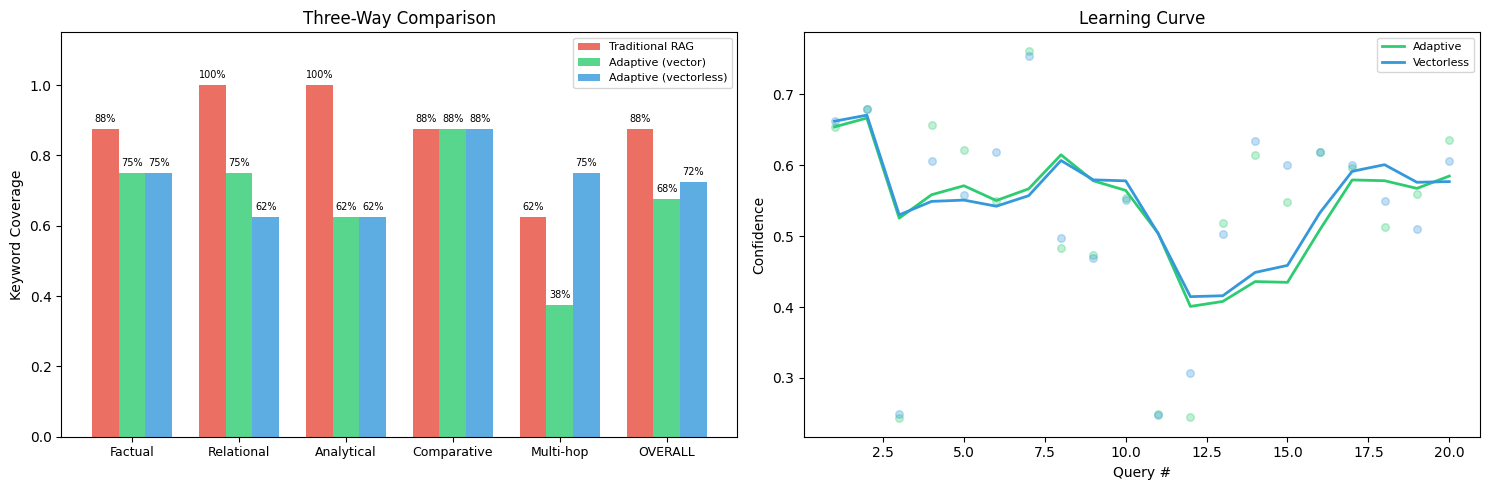

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def avg_cat(results, cat):
    vals = [r['cov'] for r in results if r['cat'] == cat]
    return sum(vals)/len(vals) if vals else 0

labels = cat_names + ['OVERALL']
t_v = [avg_cat(R['trad'], c) for c in cats] + [sum(r['cov'] for r in R['trad'])/20]
a_v = [avg_cat(R['adapt'], c) for c in cats] + [sum(r['cov'] for r in R['adapt'])/20]
v_v = [avg_cat(R['vless'], c) for c in cats] + [sum(r['cov'] for r in R['vless'])/20]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(labels))
w = 0.25
ax1.bar(x-w, t_v, w, label='Traditional RAG', color='#E74C3C', alpha=0.8)
ax1.bar(x, a_v, w, label='Adaptive (vector)', color='#2ECC71', alpha=0.8)
ax1.bar(x+w, v_v, w, label='Adaptive (vectorless)', color='#3498DB', alpha=0.8)
ax1.set_ylabel('Keyword Coverage')
ax1.set_title('Three-Way Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylim(0, 1.15)
ax1.legend(fontsize=8)
for i in range(len(labels)):
    ax1.text(i-w, t_v[i]+0.02, f'{t_v[i]:.0%}', ha='center', fontsize=7)
    ax1.text(i, a_v[i]+0.02, f'{a_v[i]:.0%}', ha='center', fontsize=7)
    ax1.text(i+w, v_v[i]+0.02, f'{v_v[i]:.0%}', ha='center', fontsize=7)

confs_a = [r['conf'] for r in R['adapt']]
confs_v = [r['conf'] for r in R['vless']]
def roll(v, w=5): return [sum(v[max(0,i-w+1):i+1])/len(v[max(0,i-w+1):i+1]) for i in range(len(v))]
ax2.plot(range(1,21), roll(confs_a), color='#2ECC71', lw=2, label='Adaptive')
ax2.plot(range(1,21), roll(confs_v), color='#3498DB', lw=2, label='Vectorless')
ax2.scatter(range(1,21), confs_a, color='#2ECC71', alpha=0.3, s=30)
ax2.scatter(range(1,21), confs_v, color='#3498DB', alpha=0.3, s=30)
ax2.set_xlabel('Query #')
ax2.set_ylabel('Confidence')
ax2.set_title('Learning Curve')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/results_local.png', dpi=150)
plt.show()


## Step 11: Summary

In [12]:
print('=' * 70)
print(f'{"Category":<14} {"Trad RAG":>10} {"Adaptive":>10} {"Vectorless":>10}')
print('-' * 70)
for cat, name in zip(cats, cat_names):
    tc = avg_cat(R['trad'], cat)
    ac = avg_cat(R['adapt'], cat)
    vc = avg_cat(R['vless'], cat)
    print(f'{name:<14} {tc:>9.0%} {ac:>9.0%} {vc:>9.0%}')
to = sum(r['cov'] for r in R['trad'])/20
ao = sum(r['cov'] for r in R['adapt'])/20
vo = sum(r['cov'] for r in R['vless'])/20
print('-' * 70)
print(f'{"OVERALL":<14} {to:>9.0%} {ao:>9.0%} {vo:>9.0%}')
print('=' * 70)

sa = Counter(r['strat'] for r in R['adapt'])
sv = Counter(r['strat'] for r in R['vless'])
ga = sum(1 for r in R['adapt'] if r.get('graph'))
gv = sum(1 for r in R['vless'] if r.get('graph'))
print(f'\nStrategies: Trad=1 | Adaptive={len(sa)} | Vectorless={len(sv)}')
print(f'Graph: Trad=0 | Adaptive={ga}/20 | Vectorless={gv}/20')
print(f'Time: {total_time:.0f}s | Model: {MODEL_NAME} | GPU: local T4')


Category         Trad RAG   Adaptive Vectorless
----------------------------------------------------------------------
Factual              88%       75%       75%
Relational          100%       75%       62%
Analytical          100%       62%       62%
Comparative          88%       88%       88%
Multi-hop            62%       38%       75%
----------------------------------------------------------------------
OVERALL              88%       68%       72%

Strategies: Trad=1 | Adaptive=11 | Vectorless=14
Graph: Trad=0 | Adaptive=3/20 | Vectorless=3/20
Time: 865s | Model: Qwen/Qwen2.5-1.5B-Instruct | GPU: local T4


## Step 12: v2 Feature Demos

In [13]:
# Vectorless with page citations
resp = adaptive_vl.ask('Q3 revenue and EBITDA?')
print('Vectorless answer:', resp.answer[:250])
print(f'Confidence: {resp.confidence:.0%}')
for c in resp.citations[:3]:
    page = f', Page {c.page}' if c.page else ''
    print(f'  {c.source_document}{page}')


Vectorless answer: Based on the provided context:

**Q3 Revenue:** 
The Q3 2025 revenue for NovaTech was reported as $847 million. This figure represents the total sales generated during the third quarter of the fiscal year 2025.

**EBITDA (Earnings Before Interest, Ta
Confidence: 64%
  financial_q2.txt
  risk_assessment.txt


In [14]:
# JSON output
resp = adaptive.ask('Extract Q3 metrics', output_format='json')
print('JSON:', resp.answer[:300])
if resp.structured:
    print(f'Parsed: {type(resp.structured).__name__}')


JSON: ```json
{
  "Revenue": "$847M",
  "Product Revenue": "$612M",
  "Services Revenue": "$235M",
  "Americas Revenue": "$510M",
  "EMEA Revenue": "$220M",
  "APAC Revenue": "$117M",
  "Operating Income": "$127M",
  "EBITDA": "$168M"
}
```
Parsed: dict


In [15]:
# User feedback
resp = adaptive.ask('Top risks?')
adaptive.feedback(resp.query_id, 'good')
print('Feedback recorded: good')


Feedback recorded: good


In [16]:
# Dashboard
print(adaptive.dashboard())
print()
print(adaptive_vl.dashboard())


+---------------------------------------------------------+
|  ADAPTIVE INTELLIGENCE v2 DASHBOARD                    |
|                                                         |
|  Mode:                 Vector+Keyword                    |
|  Documents Indexed:         5                          |
|  Queries Processed:        22                          |
|  Average Accuracy:     53.8%                          |
|  Improvement Rate:     -3.2%                          |
|                                                         |
|  RL Policy:                Active                    |
|  Exploration Rate:     19.2%                          |
|  Arms Learned:             11                          |
|                                                         |
|  Graph Nodes:              53                          |
|  Graph Edges:             536                          |
|  Graph Success Rate:    0.0%                          |
+-------------------------------------------------------

---
**adaptive-intelligence v2** | Local HuggingFace | Zero Rate Limits  
[PyPI](https://pypi.org/project/adaptive-intelligence/) | [GitHub](https://github.com/VK-Ant/adaptive-intelligence) | [Paper](https://www.researchgate.net/publication/405076088)  
Also: [llmevalkit](https://pypi.org/project/llmevalkit/) (61 metrics)  
Author: Venkatkumar Rajan | @VK_Venkatkumar
